In [1]:
pip install ultralytics opencv-python matplotlib numpy

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from ultralytics import YOLO

model = YOLO("exp.pt")

print("Segmentation model loaded successfully")

Segmentation model loaded successfully


In [3]:
image_path = "crack.jpg"

results = model(
    image_path,
    imgsz=640,
    conf=0.25
)

print("Prediction completed")


image 1/1 c:\Users\OM\OneDrive\Documents\segmentation\crack.jpg: 640x640 1 crack, 437.9ms
Speed: 15.3ms preprocess, 437.9ms inference, 42.1ms postprocess per image at shape (1, 3, 640, 640)
Prediction completed


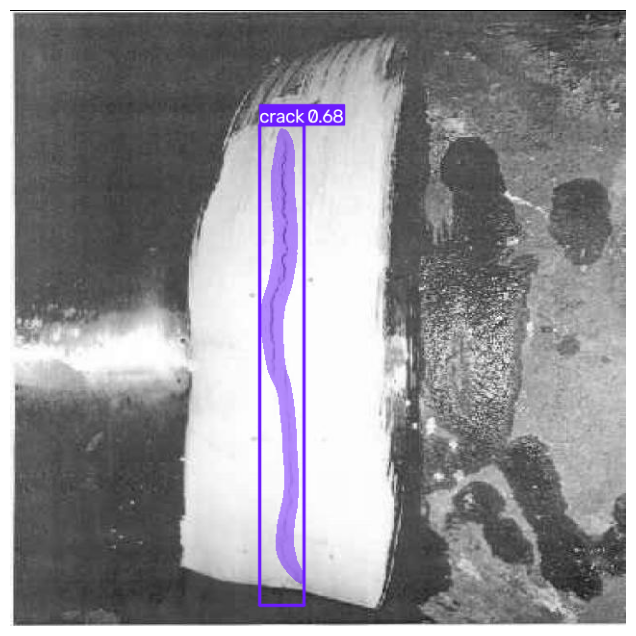

In [4]:
result = results[0]

annotated_image = result.plot()

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
plt.imshow(annotated_image)
plt.axis("off")
plt.show()

In [5]:
import numpy as np

if result.masks is not None:
    mask = result.masks.data[0].cpu().numpy()

    # Convert mask to binary
    binary_mask = mask > 0

    # Count defect pixels
    defect_area_pixels = np.sum(binary_mask)

    print("Defect area:", defect_area_pixels, "pixels")
else:
    print("No mask detected")

Defect area: 9561 pixels


In [6]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from skimage.morphology import skeletonize

# Convert mask to binary 0/1
binary_mask = (mask > 0).astype(np.uint8)

# Create skeleton / centerline
skeleton = skeletonize(binary_mask)

print("Skeleton pixels:", skeleton.sum())

Skeleton pixels: 465


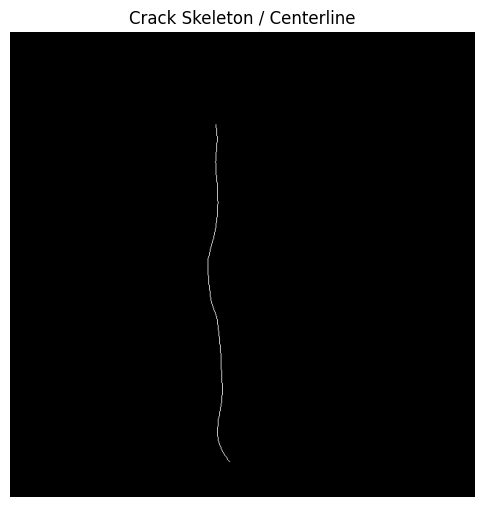

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 8))
plt.imshow(skeleton, cmap="gray")
plt.title("Crack Skeleton / Centerline")
plt.axis("off")
plt.show()

In [9]:
# Get coordinates of skeleton pixels
y, x = np.where(skeleton)

# Calculate approximate length
length_pixels = 0

for i in range(1, len(x)):
    dx = x[i] - x[i - 1]
    dy = y[i] - y[i - 1]

    # Distance between consecutive pixels
    length_pixels += np.sqrt(dx**2 + dy**2)

print("Approximate crack length:", round(length_pixels, 2), "pixels")

Approximate crack length: 491.75 pixels


In [10]:
from skimage.graph import route_through_array
import numpy as np

# Get skeleton coordinates
y, x = np.where(skeleton)

# Find two farthest skeleton points
coords = np.column_stack((y, x))

max_dist = 0
start = None
end = None

for i in range(len(coords)):
    distances = np.sum((coords - coords[i]) ** 2, axis=1)
    j = np.argmax(distances)

    if distances[j] > max_dist:
        max_dist = distances[j]
        start = tuple(coords[i])
        end = tuple(coords[j])

# Cost map:
# skeleton pixels = 1
# non-skeleton pixels = very high cost
cost = np.where(skeleton, 1, 1000).astype(float)

# Find path along the skeleton
path, cost_value = route_through_array(
    cost,
    start,
    end,
    fully_connected=True
)

# Calculate length of the path
length_pixels = 0

for i in range(1, len(path)):
    dy = path[i][0] - path[i-1][0]
    dx = path[i][1] - path[i-1][1]

    length_pixels += np.sqrt(dx**2 + dy**2)

print("Improved crack length:", round(length_pixels, 2), "pixels")

Improved crack length: 491.75 pixels


In [11]:
# Final Defect Measurement Output

defect_type = result.names[int(result.boxes.cls[0])]
confidence = float(result.boxes.conf[0])

print("========== DEFECT MEASUREMENT ==========")
print(f"Defect Type : {defect_type.capitalize()}")
print(f"Confidence  : {confidence * 100:.1f}%")
print(f"Crack Length: {length_pixels:.2f} px")
print(f"Crack Area  : {defect_area_pixels:.0f} px²")
print("========================================")

========== DEFECT MEASUREMENT ==========
Defect Type : Crack
Confidence  : 68.3%
Crack Length: 491.75 px
Crack Area  : 9561 px²


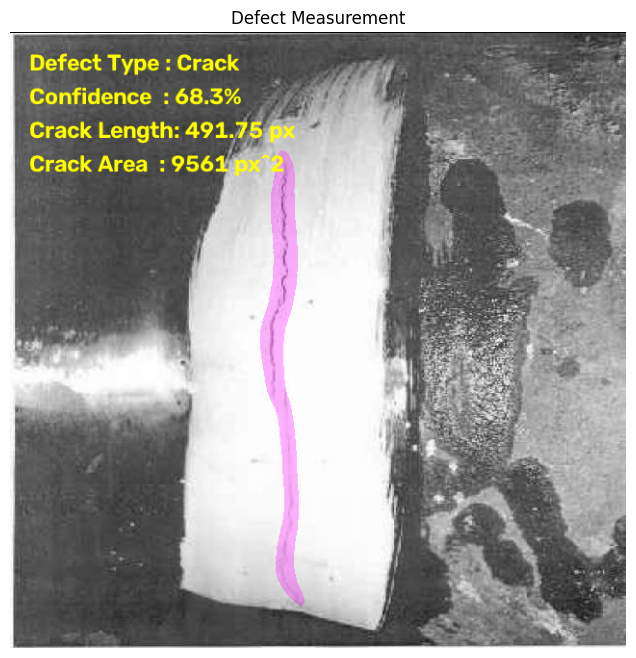

In [12]:
import cv2
import matplotlib.pyplot as plt

# Get original image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw the segmentation mask
mask_uint8 = (binary_mask * 255).astype(np.uint8)

# Create colored overlay
overlay = img.copy()
overlay[mask_uint8 > 0] = [255, 0, 255]

# Blend original + mask
output_img = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

# Text information
defect_type = result.names[int(result.boxes.cls[0])]
confidence = float(result.boxes.conf[0])

text_lines = [
    f"Defect Type : {defect_type.capitalize()}",
    f"Confidence  : {confidence * 100:.1f}%",
    f"Crack Length: {length_pixels:.2f} px",
    f"Crack Area  : {defect_area_pixels:.0f} px^2"
]

# Write text on image
y = 40
for text in text_lines:
    cv2.putText(
        output_img,
        text,
        (20, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 0),
        2,
        cv2.LINE_AA
    )
    y += 35

# Show final image
plt.figure(figsize=(10, 8))
plt.imshow(output_img)
plt.axis("off")
plt.title("Defect Measurement")
plt.show()

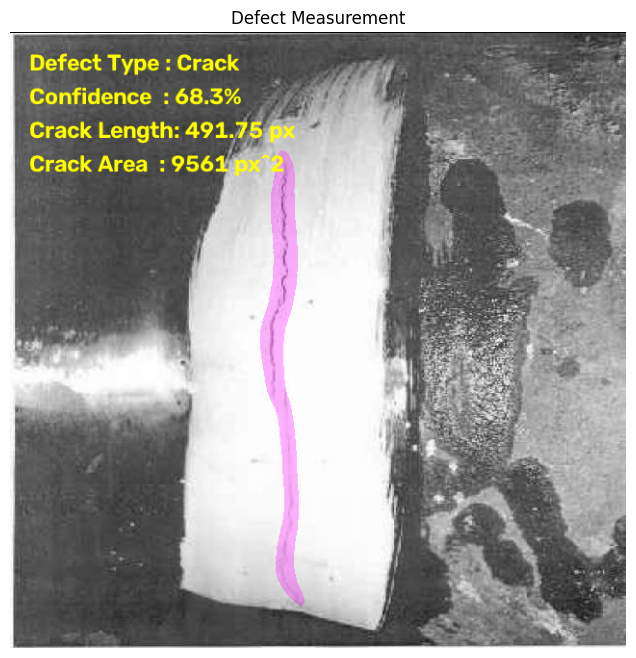

In [13]:
import cv2
import matplotlib.pyplot as plt

# Get original image
img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Draw the segmentation mask
mask_uint8 = (binary_mask * 255).astype(np.uint8)

# Create colored overlay
overlay = img.copy()
overlay[mask_uint8 > 0] = [255, 0, 255]

# Blend original + mask
output_img = cv2.addWeighted(img, 0.7, overlay, 0.3, 0)

# Text information
defect_type = result.names[int(result.boxes.cls[0])]
confidence = float(result.boxes.conf[0])

text_lines = [
    f"Defect Type : {defect_type.capitalize()}",
    f"Confidence  : {confidence * 100:.1f}%",
    f"Crack Length: {length_pixels:.2f} px",
    f"Crack Area  : {defect_area_pixels:.0f} px^2"
]

# Write text on image
y = 40
for text in text_lines:
    cv2.putText(
        output_img,
        text,
        (20, y),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 0),
        2,
        cv2.LINE_AA
    )
    y += 35

# Show final image
plt.figure(figsize=(10, 8))
plt.imshow(output_img)
plt.axis("off")
plt.title("Defect Measurement")
plt.show()

In [14]:
from ipywidgets import FileUpload
from IPython.display import display

upload = FileUpload(
    accept='image/*',
    multiple=False
)

display(upload)

FileUpload(value=(), accept='image/*', description='Upload')

In [16]:
# Get uploaded file
uploaded_file = upload.value[0]

filename = uploaded_file["name"]
file_data = uploaded_file["content"]

print("Uploaded:", filename)

Uploaded: 007.png


In [19]:
from PIL import Image
import io

image = Image.open(io.BytesIO(file_data)).convert("RGB")

image_path = "live_test.jpg"
image.save(image_path)

print("Image saved:", image_path)

Image saved: live_test.jpg


In [20]:
# Run YOLO segmentation on uploaded image

results = model(
    "live_test.jpg",
    imgsz=640,
    conf=0.25
)

result = results[0]

print("Prediction completed")


image 1/1 c:\Users\OM\OneDrive\Documents\segmentation\live_test.jpg: 640x640 (no detections), 795.1ms
Speed: 156.8ms preprocess, 795.1ms inference, 36.6ms postprocess per image at shape (1, 3, 640, 640)
Prediction completed
